/tmp/ipykernel_86193/2976015602.py:54: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=1.0)


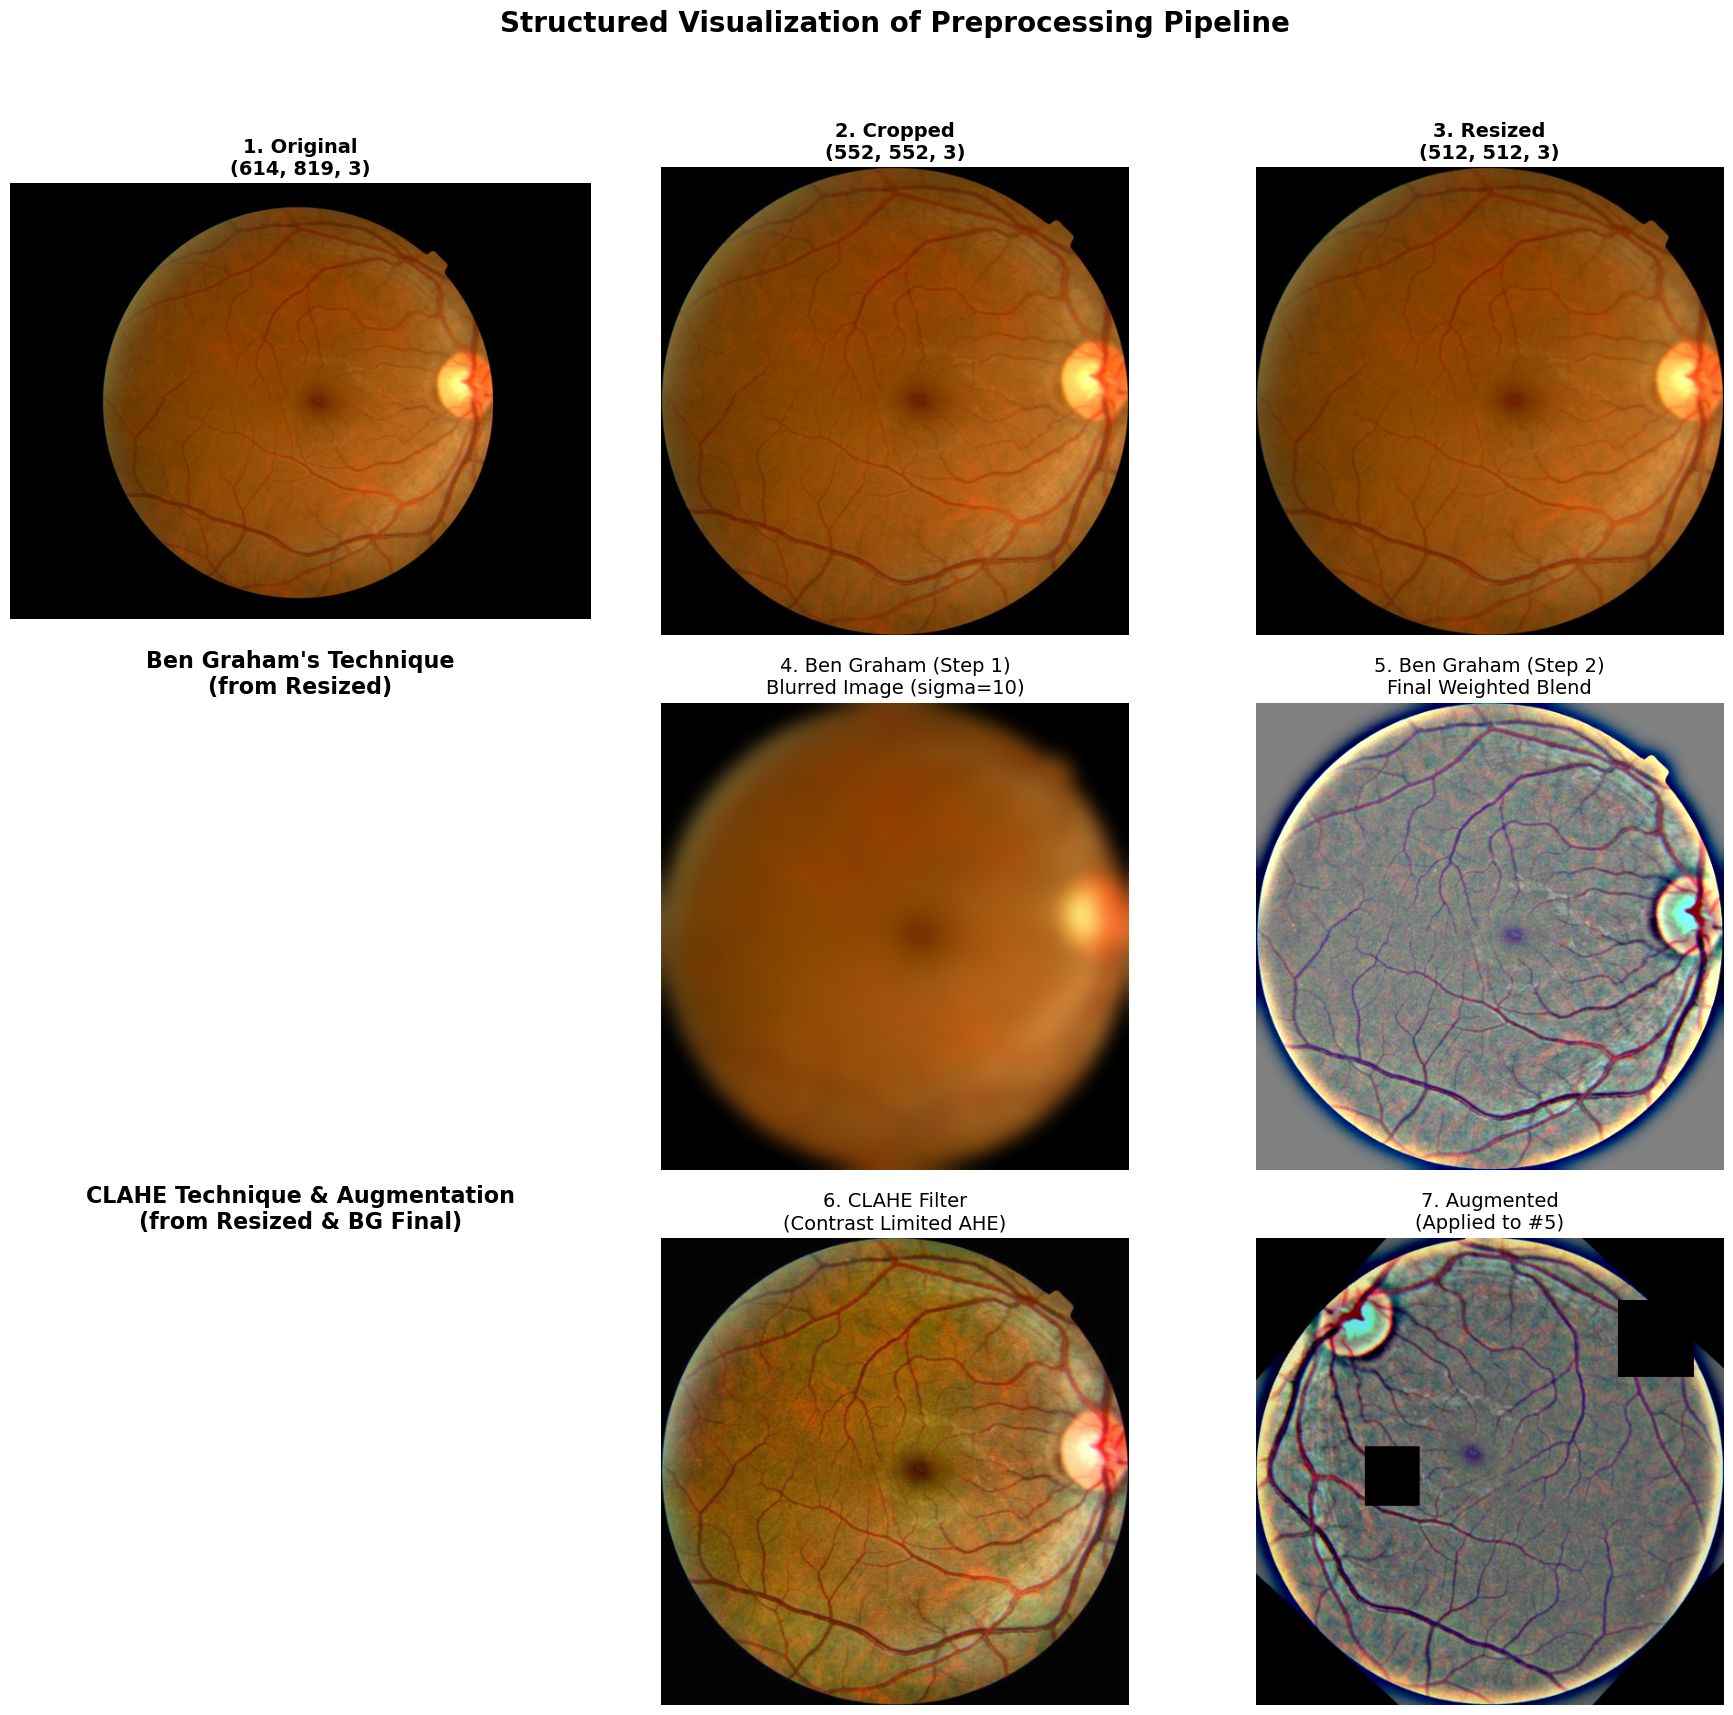

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A

class Config:
    image_size = 512

cfg = Config()

def crop_black_borders(img: np.ndarray, tol: int = 7) -> np.ndarray:
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol
    if mask.sum() == 0:
        return img
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

def apply_clahe_color(img: np.ndarray, clip_limit: float = 2.0, tile_size: int = 8) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    
    r, g, b = cv2.split(img)
    
    cl_r = clahe.apply(r)
    cl_g = clahe.apply(g)
    cl_b = clahe.apply(b)
    
    cl_img = cv2.merge((cl_r, cl_g, cl_b))
    return cl_img

def visualize_pipeline(image_path: str):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"Error: Could not read image at {image_path}")
        return
        
    img_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    img_cropped = crop_black_borders(img_original)
    
    img_resized = cv2.resize(img_cropped, (cfg.image_size, cfg.image_size))
    
    img_blurred = cv2.GaussianBlur(img_resized, (0, 0), sigmaX=10)
    
    img_ben_graham = cv2.addWeighted(img_resized, 4, img_blurred, -4, 128)
    
    img_clahe = apply_clahe_color(img_resized)
    
    aug_transforms = A.Compose([
        A.HorizontalFlip(p=1.0),
        A.Rotate(limit=45, p=1.0, border_mode=cv2.BORDER_CONSTANT),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=1.0)
    ])
    
    img_augmented = aug_transforms(image=img_ben_graham)["image"]

    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    fig.suptitle("Structured Visualization of Preprocessing Pipeline", fontsize=20, fontweight='bold')

    for ax in axes.flatten():
        ax.axis("off")

    axes[0, 0].imshow(img_original)
    axes[0, 0].set_title(f"1. Original\n{img_original.shape}", fontsize=14, fontweight='bold')

    axes[0, 1].imshow(img_cropped)
    axes[0, 1].set_title(f"2. Cropped\n{img_cropped.shape}", fontsize=14, fontweight='bold')

    axes[0, 2].imshow(img_resized)
    axes[0, 2].set_title(f"3. Resized\n{img_resized.shape}", fontsize=14, fontweight='bold')

    axes[1, 0].set_title("Ben Graham's Technique\n(from Resized)", fontsize=16, fontweight='bold')

    axes[1, 1].imshow(img_blurred)
    axes[1, 1].set_title("4. Ben Graham (Step 1)\nBlurred Image (sigma=10)", fontsize=14)

    axes[1, 2].imshow(img_ben_graham)
    axes[1, 2].set_title("5. Ben Graham (Step 2)\nFinal Weighted Blend", fontsize=14)

    axes[2, 0].set_title("CLAHE Technique & Augmentation\n(from Resized & BG Final)", fontsize=16, fontweight='bold')

    axes[2, 1].imshow(img_clahe)
    axes[2, 1].set_title("6. CLAHE Filter\n(Contrast Limited AHE)", fontsize=14)

    axes[2, 2].imshow(img_augmented)
    axes[2, 2].set_title("7. Augmented\n(Applied to #5)", fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()

image_path = "01d9477b1171.png" 
visualize_pipeline(image_path)

/tmp/ipykernel_86193/524485062.py:35: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  ("ElasticTransform", A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)),
/tmp/ipykernel_86193/524485062.py:45: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  ("GaussNoise", A.GaussNoise(var_limit=(500, 500), p=1.0)),
/tmp/ipykernel_86193/524485062.py:48: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  ("CoarseDropout", A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=8, fill_value=0, p=1.0)),
/tmp/ipykernel_86193/524485062.py:49: UserWarning: Argument(s) 'unit_size_min, unit_size_max, fill_value' are not valid for transform GridDropout
  ("GridDropout", A.GridDropout(ratio=0.5, unit_size_min=20, unit_size_max=20, fill_value=128, p=1.0)),


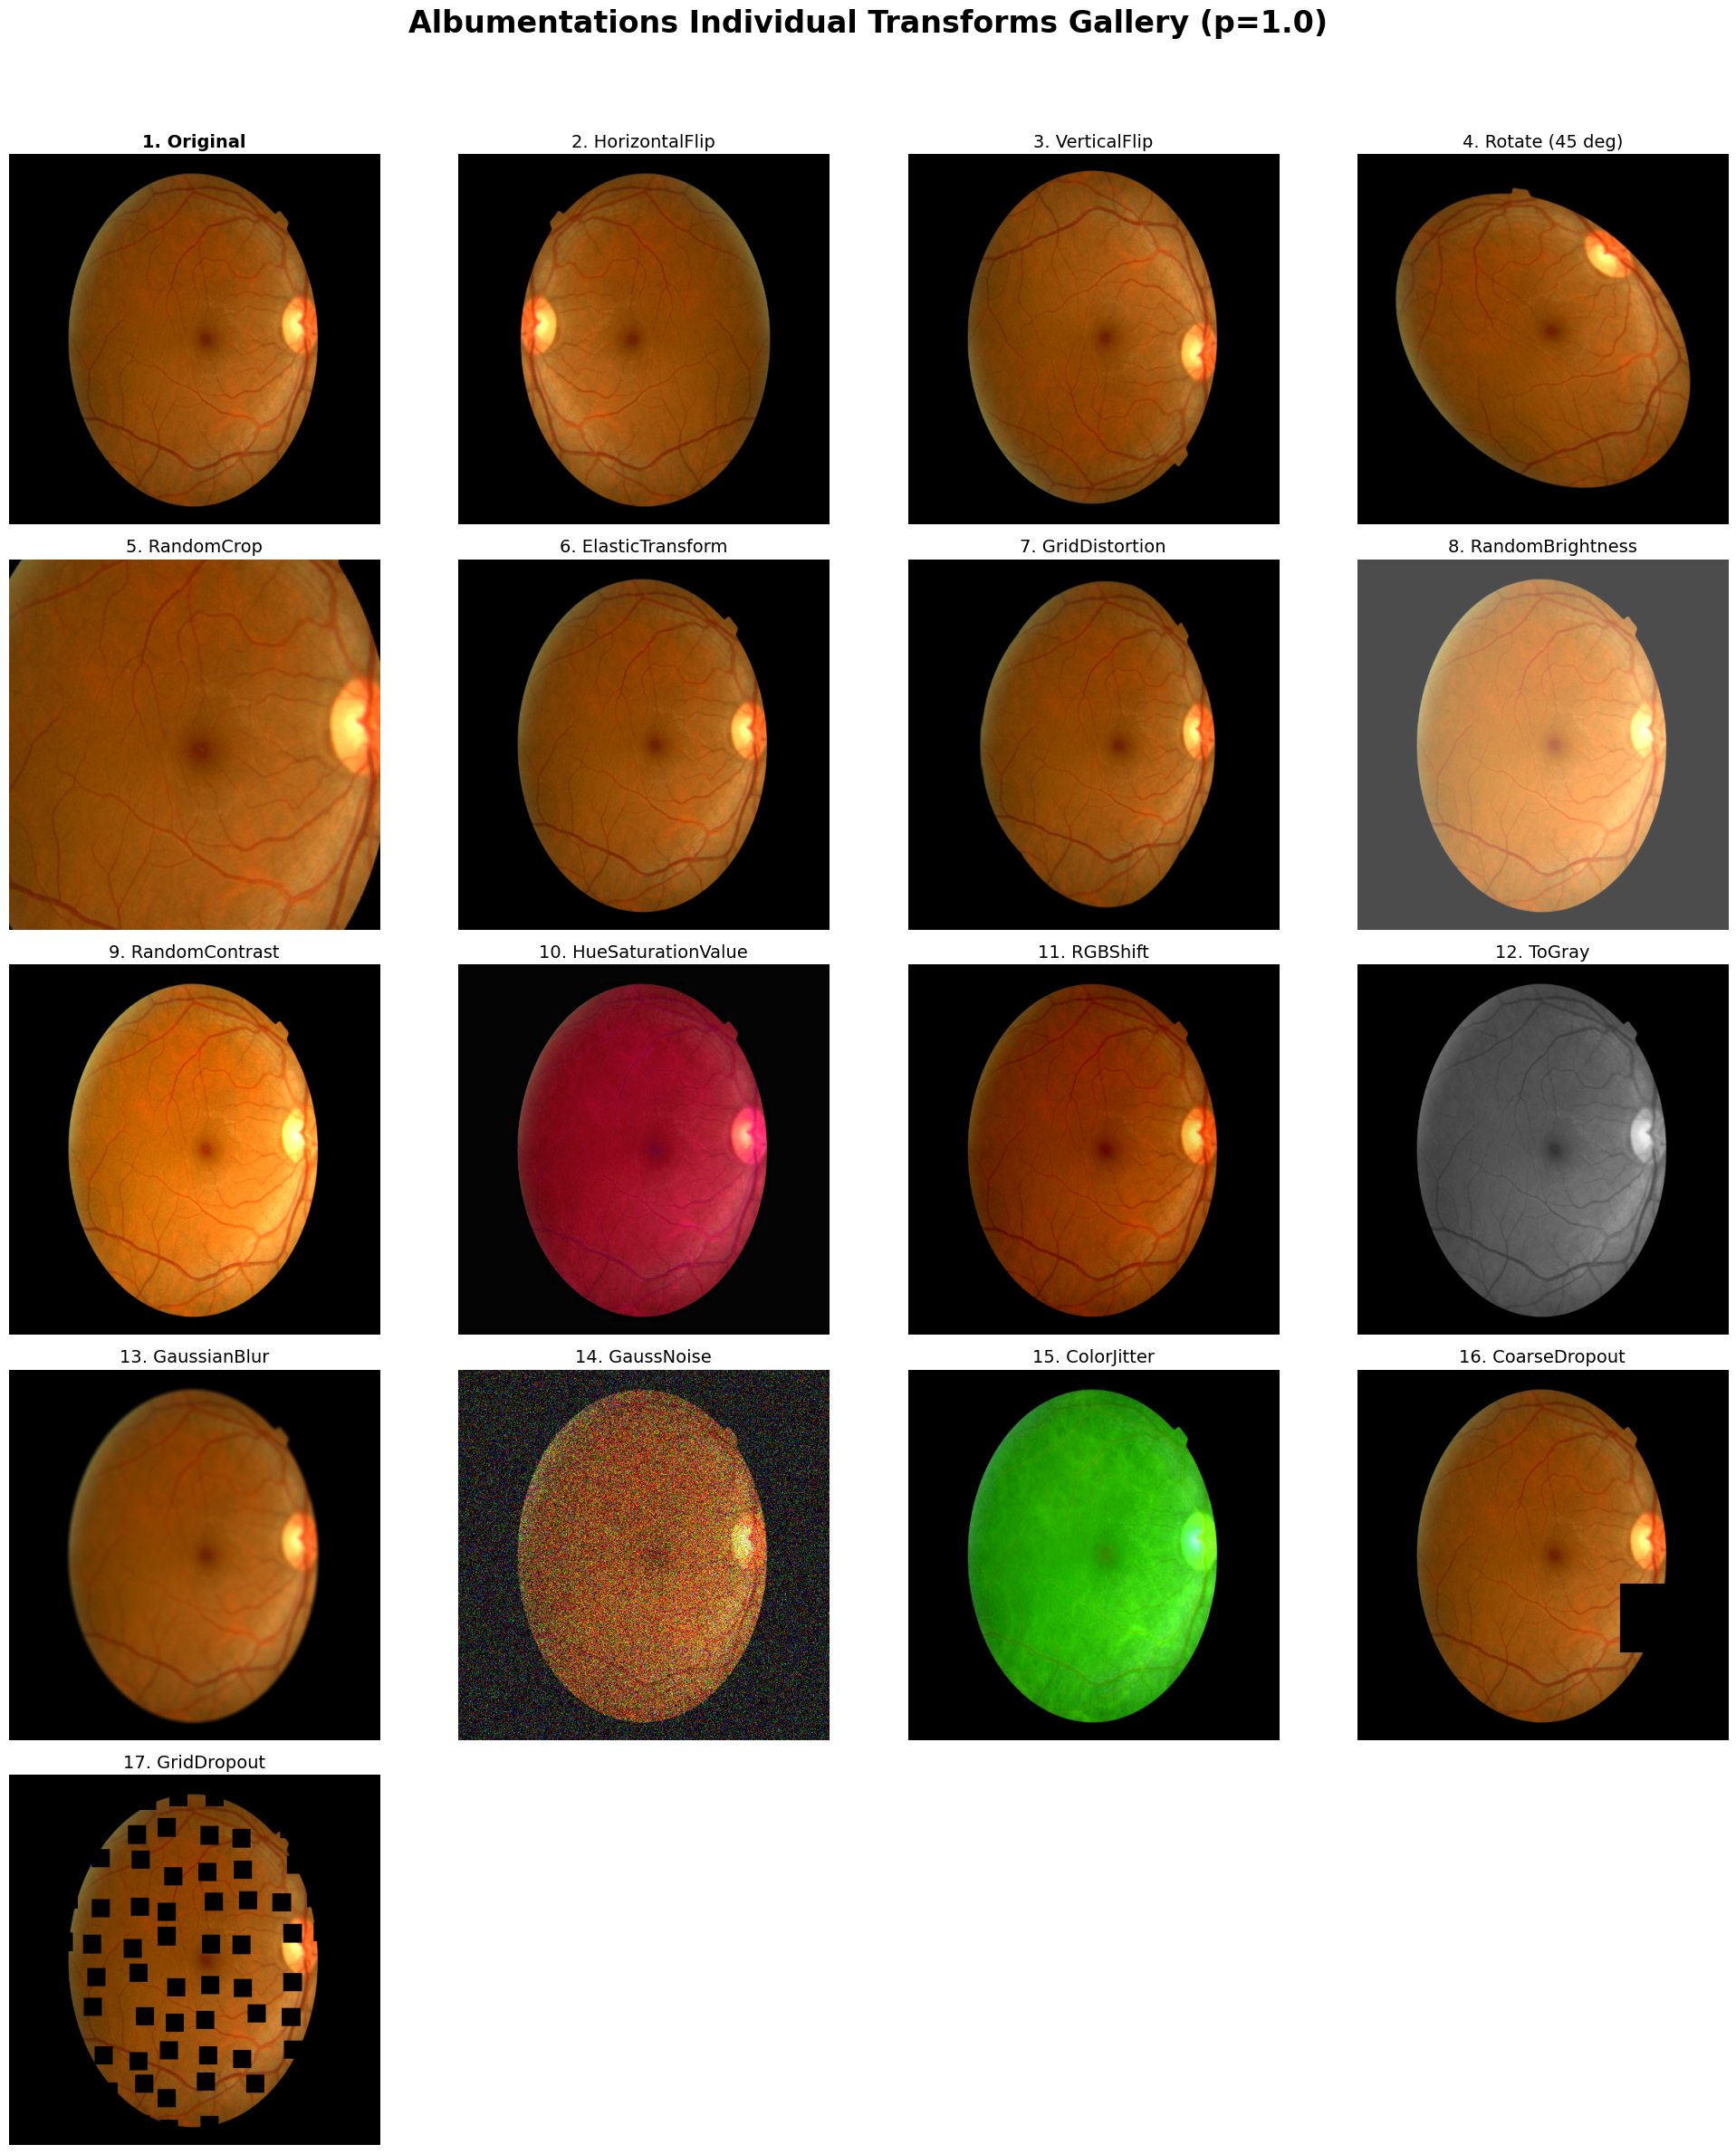

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import math

IMAGE_PATH = "01d9477b1171.png" 

def load_base_image(path, size=512):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f"Warning: Could not read image at {path}. Generating a synthetic image for demonstration.")
        img = np.zeros((size, size, 3), np.uint8)
        grid_size = size // 8
        for i in range(8):
            for j in range(8):
                color = [((i+j)%2)*255, (i*30)%255, (j*30)%255]
                img[i*grid_size:(i+1)*grid_size, j*grid_size:(j+1)*grid_size] = color
        cv2.circle(img, (size//2, size//2), size//4, (255, 255, 255), 5)
        cv2.putText(img, 'F', (size//4, 3*size//4), cv2.FONT_HERSHEY_SIMPLEX, 8, (255, 255, 255), 10)
        return img
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (size, size))
    return img_resized

original_img = load_base_image(IMAGE_PATH)

transform_tests = [
    ("Original", None),
    ("HorizontalFlip", A.HorizontalFlip(p=1.0)),
    ("VerticalFlip", A.VerticalFlip(p=1.0)),
    ("Rotate (45 deg)", A.Rotate(limit=(45, 45), p=1.0, border_mode=cv2.BORDER_CONSTANT)),
    ("RandomCrop", A.RandomCrop(width=300, height=300, p=1.0)),
    ("ElasticTransform", A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1.0)),
    ("GridDistortion", A.GridDistortion(p=1.0)),

    ("RandomBrightness", A.RandomBrightnessContrast(brightness_limit=(0.3, 0.3), contrast_limit=0, p=1.0)),
    ("RandomContrast", A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.5, 0.5), p=1.0)),
    ("HueSaturationValue", A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1.0)),
    ("RGBShift", A.RGBShift(r_shift_limit=50, g_shift_limit=50, b_shift_limit=50, p=1.0)),
    ("ToGray", A.ToGray(p=1.0)),

    ("GaussianBlur", A.GaussianBlur(blur_limit=(7, 7), p=1.0)),
    ("GaussNoise", A.GaussNoise(var_limit=(500, 500), p=1.0)),
    ("ColorJitter", A.ColorJitter(p=1.0)),

    ("CoarseDropout", A.CoarseDropout(max_holes=8, max_height=64, max_width=64, min_holes=8, fill_value=0, p=1.0)),
    ("GridDropout", A.GridDropout(ratio=0.5, unit_size_min=20, unit_size_max=20, fill_value=128, p=1.0)),
]

num_transforms = len(transform_tests)
cols = 4 
rows = math.ceil(num_transforms / cols) 

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
fig.suptitle("Albumentations Individual Transforms Gallery (p=1.0)", fontsize=24, fontweight='bold', y=0.98)

axes_flat = axes.flatten()

for i, (name, transform) in enumerate(transform_tests):
    ax = axes_flat[i]
    
    if transform is not None:
        augmented_struct = transform(image=original_img)
        augmented_img = augmented_struct["image"]
    else:
        augmented_img = original_img
    
    ax.imshow(augmented_img)
    
    title_text = f"{i+1}. {name}"
    ax.set_title(title_text, fontsize=14, fontweight='bold' if transform is None else 'normal')
    ax.axis("off") 

for j in range(num_transforms, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()